# Support Vector Machines

In [1]:
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

iris = load_iris()

In [2]:
# Take the first two features of the dataset
X = iris.data[:, :2]
y = iris.target

In [3]:
# Select two classes, e.g., class 0 (setosa) and class 1 (versicolor)
mask = (y == 0) | (y == 1)
X_ = X[mask]
y_ = y[mask]

In [4]:
# Split into training and test using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
import numpy as np

def plot_svc_decision_function(model, ax=None, plot_support=True):
   
    if ax is None:
        ax = plt.gca()
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 40)
    y = np.linspace(ylim[0], ylim[1], 40)
    
    # creates a 2D grid of coordinates (X and Y) based on the x and y values.
    Y, X = np.meshgrid(y, x)
    
    # reshapes the grid into a 2D array of (x, y) coordinates.
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',
                   facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

Alphas*label in dual SVM for the support vectors are : [[-3.09159003 -8.36668702  9.10251138  2.35576567]]


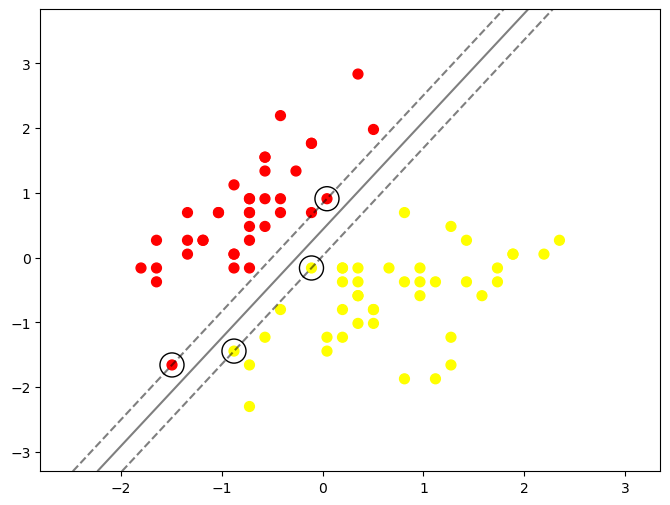

In [7]:
def plot_svm(X, y, ax=None):
    # Train SVM on the provided data
    model = SVC(kernel='linear', C=100)
    model.fit(X, y)
    
    print("Alphas*label in dual SVM for the support vectors are :", model.dual_coef_)

    # Plot data
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    
    # Adjust plot limits automatically based on your data
    ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1)
    ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
   
    
    # Plot SVM decision boundary
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(figsize=(8, 6))
plot_svm(X_train, y_train, ax)
plt.show()

# Kernels in SVM

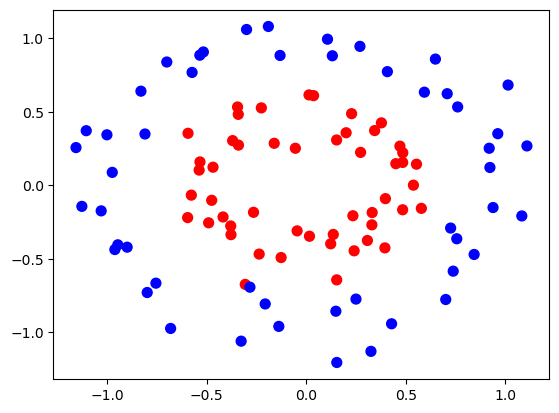

In [8]:
from sklearn.datasets import make_circles
X_c, y_c = make_circles(100, factor=.5, noise=.1)

plt.scatter(X_c[:, 0], X_c[:, 1], c=y_c, s=50, cmap='bwr')

In [9]:
X_tr, X_ts, y_tr, y_ts = train_test_split(X_c, y_c, test_size = 0.20)

In [10]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

In [11]:
lin_classifier = SVC(kernel="linear")#Let see if we can classify the non-linear data using the linear SVM
lin_classifier.fit(X_tr, y_tr)
y_prd = lin_classifier.predict(X_tr)

In [12]:
accuracy_score(y_tr, y_prd) #Linear Classifier won't work since the data is non-linear. #Accuracy is low

0.5375

In [14]:
#What if we transform the data and add non-linear features 
def transform_data(X):
    #r = np.exp(-(X ** 2).sum(1))
    z = np.array([X[:,0]**2, np.sqrt(2)*X[:,0]*X[:,1], X[:,1]**2])
    z = z.T
    return z

X_ = transform_data(X_tr)

In [15]:
def plot_3d_plot(X, y):
    z = np.array([X[:,0]**2, np.sqrt(2)*X[:,0]*X[:,1], X[:,1]**2])
    z = z.T
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:,0], X[:,1], X[:,2], c=y, s=100, cmap='bwr')
    ax.set_xlabel('z2')
    ax.set_ylabel('z1')
    ax.set_zlabel('z3')

    ax.view_init(elev=0, azim=270)
    return ax

<Axes3D: xlabel='z2', ylabel='z1', zlabel='z3'>

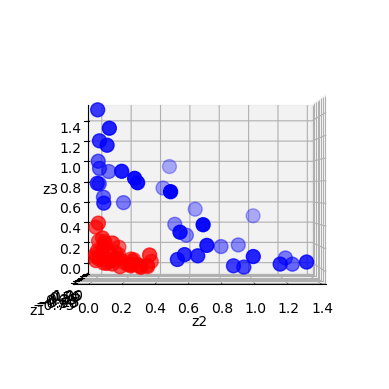

In [16]:
plot_3d_plot(X_,y_tr) #Data is very much separable now in higher dimensions

In [17]:
#Let us now classify the transformed features using a linear SVM
lin_classifier = SVC(kernel="linear")
lin_classifier.fit(X_, y_tr)
y_prd = lin_classifier.predict(X_)

In [18]:
accuracy_score(y_tr, y_prd) #The accuracy is now very close to 100%

0.9875

In [19]:
#Let us now use kernel trick and train the model on original features
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_tr, y_tr)
y_prd = poly_classifier.predict(X_ts)

/var/folders/62/qs95j57n63b7t6v7jp6rdtx80000gn/T/ipykernel_48633/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


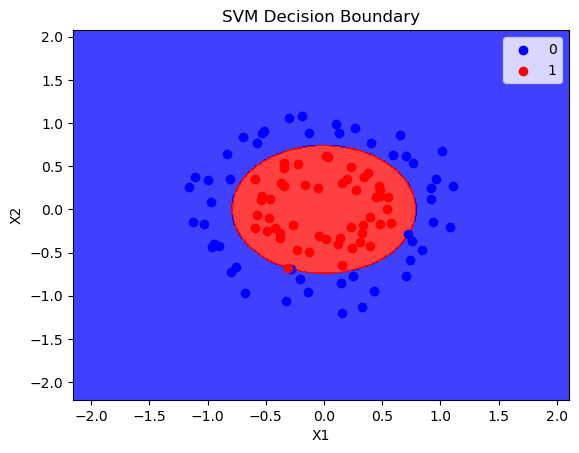

In [20]:
plot_decision_boundary(X_c, y_c, poly_classifier)